# Sturm und Drang vs. Klassik: un classificatore *solo lessicale*

**Domanda di ricerca.** Un modello che vede solo il lessico di testi teatrali riesce a distinguere "Sturm und Drang" da "Klassik"?

**Corpus (7 drammi).**

| Classe | Opere |
|---|---|
| Sturm und Drang | *Die Räuber* (Schiller), *Götz von Berlichingen* (Goethe), *Der Hofmeister* (Lenz) |
| Klassik | *Iphigenie auf Tauris* (Goethe), *Wallenstein* (Schiller), *Maria Stuart* (Schiller) |

**Pipeline.** caricamento
pulizia (didascalie, nomi dei parlanti)
normalizzazione ortografica
lemmatizzazione (spaCy)
finestre da circa 200 parole
TF-IDF + word2vec
regressione logistica
valutazione

**Tre cautele metodologiche** (le riprenderemo nei commenti, sono materiale per la discussione critica):
1. **Ortografia delle edizioni.** Alcuni testi hanno ortografia ottocentesca (*Rath*, *seyn*, *Thür*), altri modernizzata.
2. **Verso vs. prosa.** Le tre opere Klassik sono in versi, le tre Sturm und Drang in prosa
3. **Pochissime opere.** Con 6 opere etichettate, le finestre della stessa opera non sono indipendenti: l'accuratezza per finestra è gonfiata. Per questo oltre allo split richiesto usiamo la *leave-one-work-out* (LOWO): A ogni giro viene tenuta fuori un'opera intera come test e il modello viene addestrato sulle altre 5.


In [50]:
!pip -q install spacy gensim scikit-learn matplotlib pandas beautifulsoup4
!python -m spacy download de_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 92.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [51]:
import re, os, zipfile, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
pd.set_option("display.width", 160)

## 2. Pulizia

In [ ]:
DATA_DIR = "/content/corpus"      # cartella dove mettere i 7 file

SD, KL = "Sturm und Drang", "Klassik"

WORKS = {
    "Die Räuber":            dict(file="die-raeuber.epub",                  cls=SD, author="Schiller"),
    "Götz von Berlichingen": dict(file="goetz-von-berlichingen.epub",       cls=SD, author="Goethe"),
    "Der Hofmeister":        dict(file="jmr-lenz-der-hofmeister.epub",      cls=SD, author="Lenz"),
    "Iphigenie auf Tauris":  dict(file="iphigenie-auf-tauris.epub",         cls=KL, author="Goethe"),
    "Wallenstein":           dict(file="friedrich-schiller-wallenstein.epub", cls=KL, author="Schiller"),
    "Maria Stuart":          dict(file="maria-stuart.epub",                 cls=KL, author="Schiller"),
}

# parametri della pipeline
WINDOW        = 200                 # parole per finestra
TEXT_COL      = "lemma"             # "lemma" oppure "surface" (forma di superficie)
PRONOMI = {"ich", "mich", "mir", "du", "dich", "dir", "er", "ihn", "ihm", "sie", "ihnen", "es",
           "wir", "uns", "ihr", "euch", "man", "sich", "wer", "was",
           "mein", "dein", "sein", "unser", "euer", "dieser", "jener", "welcher"}
AUSILIARI = {"sein", "haben", "werden", "können", "müssen", "wollen", "sollen", "dürfen",
             "mögen", "lassen", "machen", "tun"}
AVVERBI_PREP = {"da", "dort", "hier", "so", "nun", "nur", "noch", "schon", "wieder", "einmal",
                "immer", "ja", "nein", "doch", "dann", "ob", "als", "wie", "weil", "dass", "daß",
                "bei", "unter", "mit", "von", "zu", "in", "an", "auf", "aus", "für", "über", "um",
                "nach", "vor", "durch", "gegen", "ohne", "bis", "und", "nicht", "kein", "mehr",
                "sehr", "ganz", "alle"}
CUSTOM_STOP = {"oder", "auch", "denn", "wenn", "aber"} | PRONOMI | AUSILIARI | AVVERBI_PREP
EXTRA_NAMES   = {
    # Wallenstein (personaggi citati nel testo ma senza battute: non sono etichette)
    "friedland", "isolan", "gallas", "altringer", "kolalto", "ferdinand", "gustav", "tilly", "oxenstirn",
    # Maria Stuart
    "stuart", "norfolk", "darnley", "bothwell", "rizzio",
    # Götz von Berlichingen
    "berlichingen", "stumpf", "hans",
    # Die Räuber
    "maximilian",
    # Der Hofmeister
    "seiffenblase", "hamster", "knicks", "rehhaar", "leopold",
    # Iphigenie: nomi mitologici (temi e personaggi solo di quest'opera)
    "agamemnon", "tantalus", "tantaliden", "atreus", "atriden", "elektra", "klytämnestra",
    "ägisth", "achill", "diana", "apoll", "zeus", "jupiter", "tauris", "delphi", "mykene", "argos", "troja",
}
FULL_STOPWORDS = False              # True = toglie anche tutte le stopword di spaCy
NORMALIZE_ORTHOGRAPHY = True
TEST_WORKS    = ["Götz von Berlichingen", "Maria Stuart"]
SPACY_MODEL   = "de_core_news_sm"
SHORT = {"Die Räuber": "Räuber", "Götz von Berlichingen": "Götz", "Der Hofmeister": "Hofmeister",
         "Iphigenie auf Tauris": "Iphigenie", "Wallenstein": "Wallenstein", "Maria Stuart": "M. Stuart"}

# parametri dei modelli
W2V = dict(vector_size=100, window=5, min_count=3, sg=1, epochs=40, seed=SEED, workers=1)
TFIDF = dict(min_df=3, sublinear_tf=True)
LR = dict(C=1.0, class_weight="balanced", max_iter=3000)
LR_W2V = dict(LR, C=0.05)   # regolarizzazione più forte: 100 feature standardizzate su poche opere > probabilità troppo estreme con C=1

## 3. Caricamento dei file
i file sono in formato epub (xhtml)

In [53]:
BLOCK = ["p","div","h1","h2","h3","h4","h5","h6","li","tr","td","th",
         "blockquote","section","dd","dt"]

def read_work(path):
    if zipfile.is_zipfile(path):
        from bs4 import BeautifulSoup
        parts = []
        with zipfile.ZipFile(path) as z:
            for n in sorted(z.namelist()):
                if n.lower().endswith((".xhtml", ".html", ".htm")):
                    soup = BeautifulSoup(z.read(n), "html.parser")
                    for br in soup.find_all("br"):
                        br.replace_with("\n")                 # a capo dei versi
                    for h in soup.find_all(re.compile(r"^h[1-6]$")):
                        h.string = "\n" + "#" * int(h.name[1]) + " " + h.get_text("", strip=True)
                    for tag in soup.find_all(BLOCK):
                        tag.append("\n")                      # a capo solo a fine blocco
                    parts.append(soup.get_text(""))           # niente separatore tra tag inline
        return "\n".join(parts)
    with open(path, encoding="utf-8") as f:
        return f.read()

In [54]:
from google.colab import files
os.makedirs(DATA_DIR, exist_ok=True)
up = files.upload()                      # scegli i 6 .epub
for name, data in up.items():
    with open(os.path.join(DATA_DIR, name), "wb") as f:
        f.write(data)
print(sorted(os.listdir(DATA_DIR)))

Saving goetz-von-berlichingen.epub to goetz-von-berlichingen (3).epub
Saving die-raeuber.epub to die-raeuber (3).epub
Saving jmr-lenz-der-hofmeister.epub to jmr-lenz-der-hofmeister (3).epub
Saving iphigenie-auf-tauris.epub to iphigenie-auf-tauris (3).epub
Saving friedrich-schiller-wallenstein.epub to friedrich-schiller-wallenstein (3).epub
Saving maria-stuart.epub to maria-stuart (3).epub
['die-raeuber (1).epub', 'die-raeuber (2).epub', 'die-raeuber (3).epub', 'die-raeuber.epub', 'friedrich-schiller-wallenstein (1).epub', 'friedrich-schiller-wallenstein (2).epub', 'friedrich-schiller-wallenstein (3).epub', 'friedrich-schiller-wallenstein.epub', 'goetz-von-berlichingen (1).epub', 'goetz-von-berlichingen (2).epub', 'goetz-von-berlichingen (3).epub', 'goetz-von-berlichingen.epub', 'iphigenie-auf-tauris (1).epub', 'iphigenie-auf-tauris (2).epub', 'iphigenie-auf-tauris (3).epub', 'iphigenie-auf-tauris.epub', 'jmr-lenz-der-hofmeister (1).epub', 'jmr-lenz-der-hofmeister (2).epub', 'jmr-lenz-d

In [55]:
RAW = {t: read_work(os.path.join(DATA_DIR, meta["file"])) for t, meta in WORKS.items()}

for t, txt in RAW.items():
    print(f"{t:24s} {len(txt):>9,} caratteri")

Die Räuber                 257,115 caratteri
Götz von Berlichingen      174,045 caratteri
Der Hofmeister             153,191 caratteri
Iphigenie auf Tauris        94,705 caratteri
Wallenstein                398,256 caratteri
Maria Stuart               397,160 caratteri


## 4. Pulizia del testo teatrale
Tolti:
* **Paratesto**: tutto ciò che precede il primo atto/scena (titolo, elenco dei personaggi, la *Vorrede* dei Räuber), le tabelle e le intestazioni.
* **Didascalie**: le parentesi `( ... )` e `[ ... ]`, più i paragrafi di descrizione della scena che seguono un'intestazione (es. *«Saal im Moorischen Schloß. Franz. Der alte Moor.»*).
* **Nomi dei parlanti**: i formati cambiano da opera a opera (`Franz.` / `Iphigenie:` / `D. a. Moor.`), quindi le etichette vengono **rilevate dai dati** (prefissi di riga che compaiono spesso) invece che con una sola regex. Subito sotto le stampo così puoi controllarle a occhio.
* **Nomi dei personaggi nel testo**: i nomi che compaiono come etichette (Franz, Wallenstein, Klärchen…) vengono tolti *ovunque*, in tutte le opere.

In [ ]:
def repair_inline_breaks(t):
    # riattacca punteggiatura e didascalie separate dal nome del parlante da un a capo
    t = re.sub(r"(?:[ \t]*\n)+[ \t]*(?=\()", " ", t)                 # "Metzler\n(leise)" > "Metzler (leise)"
    t = re.sub(r"(?:[ \t]*\n)+[ \t]*(?=[.:](?:\s|$))", "", t)        # "Sievers\n. Text"  > "Sievers. Text"
    return t

ORD = {"erster": 1, "zweiter": 2, "zweyter": 2, "dritter": 3, "vierter": 4, "fünfter": 5}
ORDW = r"(?:Erste[rs]?|Zwe[iy]te[rs]?|Dritte[rs]?|Vierte[rs]?|Fünfte[rs]?|Sechste[rs]?|Siebente[rs]?|Siebte[rs]?|Achte[rs]?|Neunte[rs]?|Zehnte[rs]?|Elfte[rs]?|Eilfte[rs]?)"
ACT_RE   = re.compile(r"^#*\s*(Erster|Zweiter|Zweyter|Dritter|Vierter|Fünfter)\s+(Aufzug|Akt)\b", re.I)
START_RE = re.compile(r"^#+\s*.*\b(Aufzug|Akt|Auftritt|Scene|Szene)\b", re.I)
PLAIN_HEAD_RE = re.compile(rf"^(?:{ORDW}\s+)?(Aufzug|Akt|Auftritt|Scene|Szene)\.?$", re.I)
HEAD = "<<HEADING>>"
MIN_LABEL_COUNT = 6

def split_into_acts(raw):
    # Restituisce [(n_atto, testo)]; scarta paratesto, tabelle, intestazioni.
    started, act, buf, acts = False, 0, [], []
    for line in raw.splitlines():
        s = line.strip()
        if s.startswith("|"):
            continue
        is_head = s.startswith("#") or bool(PLAIN_HEAD_RE.match(s))
        if is_head:
            if START_RE.match(s) or PLAIN_HEAD_RE.match(s):
                started = True
            m = ACT_RE.match(s)
            if m:
                if buf: acts.append((act, "\n".join(buf))); buf = []
                act = ORD[m.group(1).lower()]
            if started:
                buf += [HEAD]
            continue
        if started:
            buf.append(s)
    if buf: acts.append((act, "\n".join(buf)))
    return acts

def strip_stage_directions(text):
    text = re.sub(r"[ \t]*\([^()]{0,400}\)", "", text, flags=re.S)
    text = re.sub(r"[ \t]*\[[^\[\]]{0,400}\]", "", text, flags=re.S)
    return text

def label_candidates(line):
    words = line.split()
    out = []
    for i in range(1, min(5, len(words)) + 1):
        cand = " ".join(words[:i])
        if cand[-1] in ".:" and cand[0].isupper():
            out.append(cand[:-1])
    return out

NOT_LABELS = {"Ja", "Nein", "Ach", "Nun", "Ha", "Oh", "O", "Wie", "Was", "Das", "Es", "So", "Da", "Herr", "Gott", "Ihr", "Ich", "Er", "Sie", "Wir"}

def detect_labels(acts, min_count=None):
    min_count = MIN_LABEL_COUNT if min_count is None else min_count
    c = Counter()
    for _, body in acts:
        for line in strip_stage_directions(body).splitlines():
            line = line.strip()
            if line and line != HEAD:
                c.update(set(label_candidates(line)))
    return {l for l, n in c.items()
            if n >= min_count and l not in NOT_LABELS and len(l) > 1
            and not re.search(r"\b(Scene|Szene|Auftritt|Aufzug|Akt)\b", l)}

def match_label(line, labels_sorted):
    for l in labels_sorted:
        if line.startswith(l) and len(line) > len(l) and line[len(l)] in ".:":
            return l
    return None

def clean_work(raw):
    raw = repair_inline_breaks(raw)
    acts = split_into_acts(raw)
    labels = detect_labels(acts)
    labels_sorted = sorted(labels, key=len, reverse=True)
    out = []
    for act, body in acts:
        body = strip_stage_directions(body)
        lines, after_head = [], False
        for ln in body.splitlines():
            ln = ln.strip()
            if not ln:
                continue
            if ln == HEAD:
                after_head = bool(labels)
                continue
            l = match_label(ln, labels_sorted)
            if after_head:
                if l is None:
                    continue
                after_head = False
            if l:
                ln = ln[len(l) + 1:].strip()
            if ln:
                lines.append(ln)
        out.append((act, ["\n".join(lines)] if lines else []))
    return out, labels

CLEAN, LABELS = {}, {}
for t in WORKS:
    CLEAN[t], LABELS[t] = clean_work(RAW[t])

print("Etichette dei parlanti rilevate")
for t in WORKS:
    n_words = sum(len(p.split()) for _, ps in CLEAN[t] for p in ps)
    print(f"\n{t}  [{len(LABELS[t])} etichette, {n_words:,} parole dopo pulizia]:", ", ".join(sorted(LABELS[t])))

Etichette dei parlanti rilevate

Die Räuber  [20 etichette, 36,684 parole dopo pulizia]: Amalia, D. a, D. a. Moor, Daniel, Die Räuber, Franz, Grimm, Hermann, Kosinsky, Moor, Moser, Pater, R. Moor, Razmann, Roller, Räuber, Schufterle, Schwarz, Schweizer, Spiegelberg

Götz von Berlichingen  [34 etichette, 25,506 parole dopo pulizia]: Abt, Adelheid, Bischof, Brautvater, Bräutigam, Elisabeth, Erster Knecht, Erster Reiter, Franz, Fräulein, Georg, Götz, Hauptmann, Kaiser, Karl, Knecht, Kohl, Lerse, Liebetraut, Link, Maria, Martin, Metzler, Mutter, Olearius, Rat, Reiter, Ritter, Selbitz, Sickingen, Sievers, Weislingen, Zweiter Knecht, Ältester

Der Hofmeister  [17 etichette, 23,059 parole dopo pulizia]: Bollwerk, Frau Blitzer, Fritz, Geh, Geh. Rath, Graf, Gustchen, Hofmeister, Lise, Läuffer, Major, Majorin, Marthe, Pastor, Pätus, Rehaar, Wenzeslaus

Iphigenie auf Tauris  [5 etichette, 13,492 parole dopo pulizia]: Arkas, Iphigenie, Orest, Pylades, Thoas

Wallenstein  [41 etichette, 53,170 paro

In [57]:
# Ispeziona il risultato: primi 600 caratteri del testo pulito di ogni opera
for t in WORKS:
    sample = " ".join(" ".join(p) for _, p in CLEAN[t])[:600].replace("\n", " / ")
    n_words = sum(len(p.split()) for _, ps in CLEAN[t] for p in ps)
    print(f"--- {t}  ({n_words:,} parole dopo pulizia)\n{sample}\n")

--- Die Räuber  (36,684 parole dopo pulizia)
 Aber ist Euch auch wohl, Vater? Ihr seht so blaß. / Ganz wohl, mein Sohn, – was hattest du mir zu sagen? / Die Post ist angekommen – ein Brief von unserm Correspondenten in Leipzig – / Nachrichten von meinem Sohne Karl? / Hm! Hm! – So ist es. Aber ich fürchte – ich weiß nicht – ob ich – Eurer Gesundheit? – Ist Euch wirklich ganz wohl, mein Vater? / Wie dem Fisch im Wasser! Von meinem Sohne schreibt er? – Wie kommst du zu dieser Besorgniß? Du hast mich zweimal gefragt. / Wenn Ihr krank seid – nur die leiseste Ahnung habt, es zu werden, so laßt mich – ich will zu gelegenerer Zeit zu Euch reden. Diese Zeitu

--- Götz von Berlichingen  (25,506 parole dopo pulizia)
     Hänsel, noch ein Glas Branntwein, und meß christlich. / Wirt. Du bist der Nimmersatt. / Erzähl das noch einmal vom Berlichingen! Die Bamberger dort ärgern sich, sie möchten schwarz werden. / Bamberger? Was tun die hier? / Der Weislingen ist oben auf'm Schloß beim Herrn Grafen sch

## 5. Normalizzazione ortografica e diagnosi del confondente
Le edizioni non hanno la stessa ortografia. Se, per esempio, i testi ottocenteschi fossero quasi tutti Sturm und Drang, il classificatore potrebbe imparare *«Rath / seyn → Sturm und Drang»*. Due mosse:

1. **Normalizzo** le varianti più sistematiche (`th>t`, `ey>ei`), con un elenco di eccezioni per le parole moderne (*Theater, Thron, Goethe…*).
2. **Misuro** quanto l'ortografia arcaica è presente in ciascuna opera, prima e dopo.

La normalizzazione **non** è perfetta (restano *Scene*, *Correspondent*, *decorirt*…): è una mitigazione, non una soluzione. Va dichiarata nelle slide.

In [ ]:
TH_EXCEPT = ("thron", "theater", "thema", "theolog", "theor", "these", "thüring", "thymian", "therap",
             "thermo", "thomas", "goethe", "luther", "arthur", "athen", "apothek", "bibliothek", "kathol",
             "kathed", "methode", "mathem", "ethik", "äther", "ether", "lothar", "gothisch", "thekla", "theresia")

def norm_word(w):
    lw = w.lower()
    if any(x in lw for x in TH_EXCEPT):
        return w
    w = w.replace("Th", "T").replace("th", "t").replace("ey", "ei").replace("Ey", "Ei")
    return w

def normalize_orthography(text):
    text = re.sub(r"(?<=\w)['´`’](?=\w)", "", text)   # elisioni: heil'gen > heilgen, traur´ge > traurge
    return re.sub(r"[\wÄÖÜäöüß]+", lambda m: norm_word(m.group(0)), text)

## 6. Lemmatizzazione e filtro dei token
Per ogni opera teniamo **due versioni allineate** della stessa sequenza di parole: la forma di superficie (`surface`) e il lemma (`lemma`). Così puoi *valutare* se la lemmatizzazione serve (sezione 11) invece di decidere a priori.

Vengono scartati: token non alfabetici, nomi di personaggi (unione delle etichette di *tutte* le opere, per simmetria) e le parole `CUSTOM_STOP`.

In [59]:
nlp = spacy.load(SPACY_MODEL, disable=["parser", "ner"])   # ci servono solo tagger + lemmatizer
print(nlp.pipe_names)

GENERIC = {"der", "die", "das", "ein", "eine", "alle", "beide", "erster", "zweiter", "dritter", "vierter",
           "erste", "zweite", "dritte", "vierte", "alte", "alter", "junge", "junger", "andere", "anderer",
           "stimme", "stimmen", "chor", "volk", "mehrere", "einer", "und", "von", "vom", "zu", "des"}
NAMES = set()
for labs in LABELS.values():
    for l in labs:
        for w in re.findall(r"[A-ZÄÖÜ][\wäöüß]+", l):
            if len(w) >= 3 and w.lower() not in GENERIC:
                NAMES.add(w.lower())
print(f"{len(NAMES)} nomi/ruoli rimossi dal testo, es.:", sorted(NAMES)[:25])

NAMES |= EXTRA_NAMES
STOP = set(CUSTOM_STOP) | (nlp.Defaults.stop_words if FULL_STOPWORDS else set())

def is_name(surface, lemma):
    return (surface in NAMES or lemma in NAMES
            or (surface.endswith("s") and surface[:-1] in NAMES))

def tokenize_work(acts_clean, block_lines=40):
    blocks = []
    for act, paras in acts_clean:
        lines = [ln for p in paras for ln in p.splitlines()]
        for i in range(0, len(lines), block_lines):
            txt = "\n".join(lines[i:i + block_lines])
            if NORMALIZE_ORTHOGRAPHY:
                txt = normalize_orthography(txt)
            blocks.append((act, txt))
    toks = []
    for (act, _), doc in zip(blocks, nlp.pipe([b[1] for b in blocks], batch_size=8)):
        for t in doc:
            if not t.is_alpha:
                continue
            s = t.text.lower()
            l = t.lemma_.lower()
            if not l.isalpha():
                l = s
            if s in STOP or l in STOP or is_name(s, l):
                continue
            toks.append((s, l, act))
    return toks

TOKENS = {}
for t in WORKS:
    TOKENS[t] = tokenize_work(CLEAN[t])
    print(f"{t:24s} {len(TOKENS[t]):>7,} token utili")

['tok2vec', 'tagger', 'morphologizer', 'lemmatizer', 'attribute_ruler']
124 nomi/ruoli rimossi dal testo, es.: ['abt', 'adelheid', 'amalia', 'arkas', 'arkebusier', 'aubespine', 'bedienter', 'bellievre', 'bischof', 'blitzer', 'bollwerk', 'brautvater', 'bräutigam', 'burgoyn', 'burleigh', 'buttler', 'bürger', 'bürgermeister', 'daniel', 'davison', 'deveroux', 'dragoner', 'elisabeth', 'franz', 'frau']
Die Räuber                19,256 token utili
Götz von Berlichingen     12,845 token utili
Der Hofmeister            11,000 token utili
Iphigenie auf Tauris       8,149 token utili
Wallenstein               28,948 token utili
Maria Stuart              31,285 token utili


## 7. Segmentazione in finestre da circa 200 parole
Finestre **non sovrapposte** (una finestra non condivide parole con un'altra: niente perdita di informazione tra train e test). L'ultima finestra di un'opera viene tenuta solo se ha almeno metà della lunghezza.

In [60]:
def make_windows(tokens, size):
    rows = []
    for i in range(0, len(tokens), size):
        w = tokens[i:i + size]
        if len(w) < size // 2:
            continue
        acts = [a for _, _, a in w]
        rows.append(dict(text_surface=" ".join(s for s, _, _ in w),
                         text_lemma=" ".join(l for _, l, _ in w),
                         act=Counter(acts).most_common(1)[0][0],
                         n_tokens=len(w)))
    return rows

def build_df(size=WINDOW):
    recs = []
    for t, meta in WORKS.items():
        for k, r in enumerate(make_windows(TOKENS[t], size)):
            recs.append(dict(work=t, author=meta["author"], cls=meta["cls"], win=k, **r))
    return pd.DataFrame(recs)

df = build_df()
summary = df.groupby(["cls", "work"], dropna=False).size().rename("n_finestre").reset_index()
display(summary)
print("Finestre totali:", len(df))

,cls,work,n_finestre
0,Klassik,Iphigenie auf Tauris,41
1,Klassik,Maria Stuart,156
2,Klassik,Wallenstein,145
3,Sturm und Drang,Der Hofmeister,55
4,Sturm und Drang,Die Räuber,96
5,Sturm und Drang,Götz von Berlichingen,64


Finestre totali: 557


## 8. Split train/test **per opera** + baseline TF-IDF
Lo split è per opera, non per finestra: altrimenti finestre vicine della stessa opera finirebbero sia in train sia in test e il modello "riconoscerebbe l'opera" invece del genere.

* **Test**: una opera per classe, di autori diversi (`TEST_WORKS`: Goethe/Götz per SD, Schiller/Maria Stuart per Klassik).
* **Train**: le altre 4 opere. TF-IDF e IDF vengono calcolati **solo sul train**.

In [61]:
labeled = df[df.cls.notna()].reset_index(drop=True)

train = labeled[~labeled.work.isin(TEST_WORKS)].reset_index(drop=True)
test  = labeled[ labeled.work.isin(TEST_WORKS)].reset_index(drop=True)
print("Train:", train.work.value_counts().to_dict())
print("Test :", test.work.value_counts().to_dict())

def tfidf_model():
    return Pipeline([("tfidf", TfidfVectorizer(**TFIDF)), ("lr", LogisticRegression(**LR))])

def w2v_model():
    return Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(**LR_W2V))])

def p_sd(model, X):
    # probabilità di 'Sturm und Drang'
    return model.predict_proba(X)[:, list(model.classes_).index(SD)]

def report(y_true, y_pred, title):
    print(f"===== {title} =====")
    print(f"accuracy = {accuracy_score(y_true, y_pred):.3f}   macro-F1 = {f1_score(y_true, y_pred, average='macro'):.3f}")
    print(classification_report(y_true, y_pred, digits=3))

m_tfidf = tfidf_model().fit(train[f"text_{TEXT_COL}"], train.cls)
pred_tfidf = m_tfidf.predict(test[f"text_{TEXT_COL}"])
report(test.cls, pred_tfidf, "TF-IDF + regressione logistica (test)")
print("Vocabolario TF-IDF:", len(m_tfidf.named_steps["tfidf"].vocabulary_), "termini")

Train: {'Wallenstein': 145, 'Die Räuber': 96, 'Der Hofmeister': 55, 'Iphigenie auf Tauris': 41}
Test : {'Maria Stuart': 156, 'Götz von Berlichingen': 64}
===== TF-IDF + regressione logistica (test) =====
accuracy = 0.905   macro-F1 = 0.873
                 precision    recall  f1-score   support

        Klassik      0.890     0.987     0.936       156
Sturm und Drang      0.957     0.703     0.811        64

       accuracy                          0.905       220
      macro avg      0.924     0.845     0.873       220
   weighted avg      0.910     0.905     0.900       220

Vocabolario TF-IDF: 3136 termini


## 9. word2vec addestrato sul corpus + regressione logistica
Ogni finestra diventa la **media dei vettori** delle sue parole (100 dimensioni). Poi si applica la stessa regressione logistica.

**Scelta da dichiarare.** word2vec viene addestrato su *tutte* le finestre, ma **senza usare le etichette**: è apprendimento non supervisionato del lessico, non c'è fuga di etichette. Se vuoi essere più severo, cambia `W2V_TRAIN_ON = "train"`.

**Avviso onesto.** 230 mila parole sono pochissime per word2vec (i tutorial usano miliardi di parole): aspettati vicini semantici in parte sensati e in parte rumorosi. Il controllo qui sotto serve proprio a mostrarlo, ed è materiale utile per la discussione critica.

In [ ]:
W2V_TRAIN_ON = "all"   # "all" oppure "train"

def train_w2v(frame, col):
    sents = [t.split() for t in frame[col]]
    return Word2Vec(sentences=sents, **W2V).wv

def doc_vectors(texts, wv):
    X = np.zeros((len(texts), wv.vector_size))
    for i, t in enumerate(texts):
        vs = [wv[w] for w in t.split() if w in wv]
        if vs:
            X[i] = np.mean(vs, axis=0)
    return X

col = f"text_{TEXT_COL}"
wv = train_w2v(df if W2V_TRAIN_ON == "all" else train, col)
print("Vocabolario word2vec:", len(wv), "parole")

# sanity check: vicini semantici di alcune parole chiave
for w in ["freiheit", "natur", "herz", "gesetz", "pflicht", "gott", "leidenschaft", "krieg"]:
    if w in wv:
        print(f"{w:13s} >", ", ".join(f"{x} ({s:.2f})" for x, s in wv.most_similar(w, topn=6)))
    else:
        print(f"{w:13s} > (fuori vocabolario)")

Vocabolario word2vec: 4896 parole
freiheit      -> verheißen (0.56), jungfräulicher (0.55), höchst (0.54), langentbehrt (0.54), muts (0.52), unschlüssig (0.52)
natur         -> verruf (0.48), schwör (0.48), fessel (0.47), tee (0.47), zerreiß (0.47), zurückgegeben (0.47)
herz          -> freudig (0.51), weich (0.51), auferzogen (0.46), beklag (0.44), schöpfen (0.43), schilen (0.43)
gesetz        -> gehorcht (0.62), verruf (0.60), rechtfertgen (0.59), unveränderlich (0.58), prägen (0.57), unvermeidlich (0.56)
pflicht       -> unbedingt (0.55), qui (0.55), streiten (0.52), unverdrossen (0.50), bekleide (0.50), andacht (0.50)
gott          -> unterwerfung (0.51), mistreß (0.49), mäßigung (0.46), troste (0.46), unverdient (0.45), entsetzt (0.45)
leidenschaft  -> vereinigen (0.61), staunend (0.57), staatsrat (0.52), reizend (0.52), dame (0.51), anschauen (0.51)
krieg         -> leidig (0.55), zucht (0.53), bürgerlichen (0.51), europen (0.50), zuversicht (0.46), finst (0.46)


## 10. Robustezza: leave-one-work-out (LOWO)
Con un solo split la valutazione dipende da *quali* due opere hai messo nel test. Qui a turno ogni opera etichettata (6 in tutto) diventa il test e le altre 5 il train. È la misura più onesta di generalizzazione a un'opera mai vista.

In [63]:
def get_X(kind, frame, col, wv):
    return frame[col] if kind == "tfidf" else doc_vectors(frame[col], wv)

def lowo(kind, col, wv=None, frame=None):
    frame = labeled if frame is None else frame
    rows, probs = [], []
    for w in frame.work.unique():
        tr, te = frame[frame.work != w], frame[frame.work == w]
        model = (tfidf_model() if kind == "tfidf" else w2v_model()).fit(get_X(kind, tr, col, wv), tr.cls)
        Xte = get_X(kind, te, col, wv)
        pred = model.predict(Xte)
        rows.append(dict(work=w, true=te.cls.iloc[0], acc=float((pred == te.cls).mean()),
                         mean_P_SD=float(p_sd(model, Xte).mean())))
        probs.append(pd.DataFrame(dict(work=w, cls=te.cls.values, win=te.win.values, p_sd=p_sd(model, Xte))))
    return pd.DataFrame(rows), pd.concat(probs, ignore_index=True)

res_tf, probs_tf = lowo("tfidf", col)
res_w2, probs_w2 = lowo("w2v", col, wv)

cmp = res_tf.merge(res_w2, on=["work", "true"], suffixes=("_tfidf", "_w2v"))
display(cmp.round(3))
print(f"Media LOWO  TF-IDF: {res_tf.acc.mean():.3f}   word2vec: {res_w2.acc.mean():.3f}")

,work,true,acc_tfidf,mean_P_SD_tfidf,acc_w2v,mean_P_SD_w2v
0,Die Räuber,Sturm und Drang,0.542,0.512,0.740,0.690
1,Götz von Berlichingen,Sturm und Drang,0.609,0.527,0.516,0.540
2,Der Hofmeister,Sturm und Drang,1.000,0.672,1.000,0.982
3,Iphigenie auf Tauris,Klassik,0.976,0.370,1.000,0.062
4,Wallenstein,Klassik,0.421,0.525,0.497,0.542
5,Maria Stuart,Klassik,0.981,0.398,0.897,0.205


Media LOWO  TF-IDF: 0.755   word2vec: 0.775


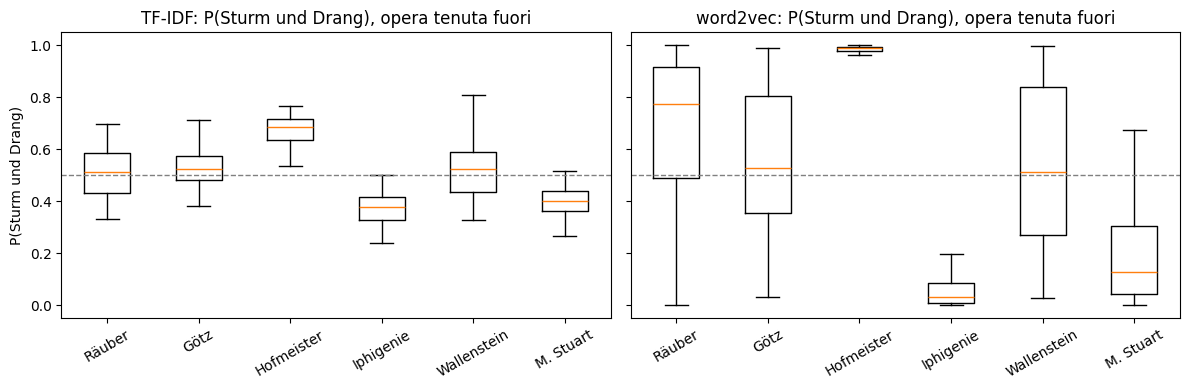

In [64]:
# Distribuzione di P(Sturm und Drang) sulle finestre di ogni opera, quando l'opera è tenuta fuori dal train
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
order = list(labeled.work.unique())
for ax, (name, pr) in zip(axes, [("TF-IDF", probs_tf), ("word2vec", probs_w2)]):
    ax.boxplot([pr[pr.work == w].p_sd for w in order], showfliers=False)
    ax.set_xticklabels([SHORT[w] for w in order])
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_title(f"{name}: P(Sturm und Drang), opera tenuta fuori")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("P(Sturm und Drang)")
plt.tight_layout(); plt.show()

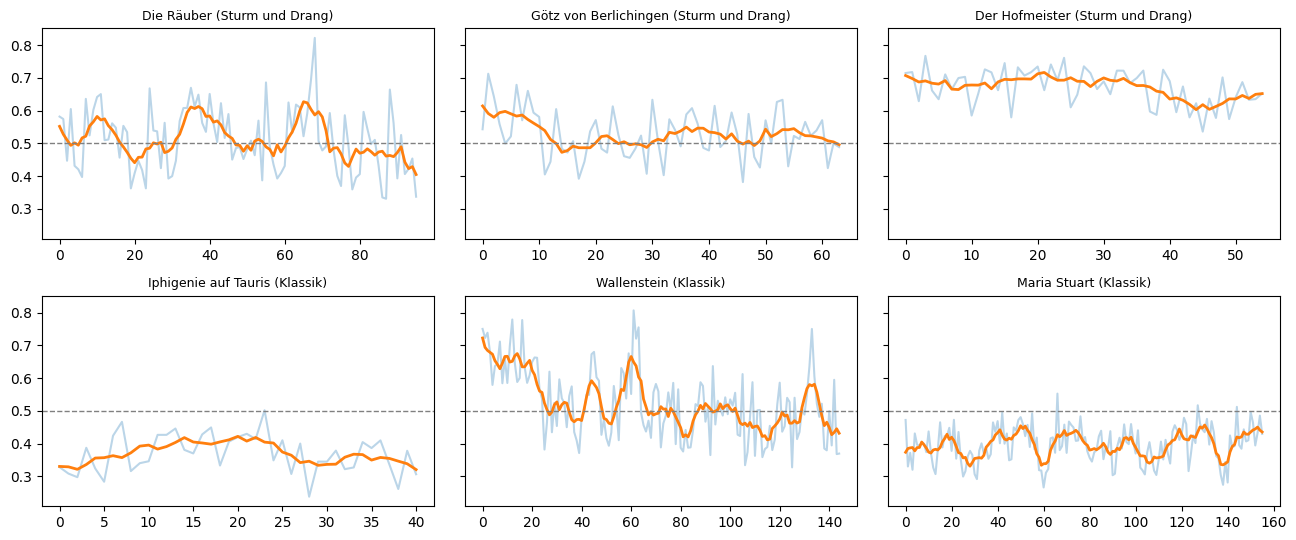

Opera più difficile: Wallenstein (acc 0.42). Finestre con l'errore più netto:

[finestra 61, P(SD)=0.81] erster hören der tumult habt gehören der weimar leben dritter oestreich feind erster der lutheraner vorhin bracht der deodat der gesundheit bliebs mäuschenstill trunk gehen viele drein ein ordentlich ohr dritter pass wohl johann der quiroga recht viel erzählen dafür viel ablaß geben vierter der stuhl deßwegen viel der führen gar verwundersam rede d ...

[finestra 12, P(SD)=0.78] mitreien absonderlich wallon ei der der allerbest schwadrone der mailand hinbegleiten der infant der kurios der pfaffe gehen der teufel los der friedländer der der soldat nobel halten der spanier ziehen feld der knauser der herz hassen der gehen laufen fort henker der verkaufen blut der hispanisch rot hut der friedländer wort credit allein reitersd ...

[finestra 16, P(SD)=0.78] mensch morden brennen der wissen gott ein elend leben möchts ein andr geben seht weit der welt rum kommen hab erfahrung nehmen hab 

In [65]:
# Dove sbaglia? Andamento di P(SD) lungo ciascuna opera (TF-IDF, opera tenuta fuori dal train)
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharey=True)
for ax, w in zip(axes.ravel(), order):
    d = probs_tf[probs_tf.work == w].sort_values("win")
    ax.plot(d.win, d.p_sd, alpha=.3); ax.plot(d.win, d.p_sd.rolling(7, center=True, min_periods=1).mean(), lw=2)
    ax.axhline(.5, color="grey", ls="--", lw=1); ax.set_title(f"{w} ({WORKS[w]['cls']})", fontsize=9)
plt.tight_layout(); plt.show()

# Le 3 finestre "più sbagliate" dell'opera con accuracy LOWO più bassa (TF-IDF)
worst = res_tf.sort_values("acc").iloc[0]
d = probs_tf[probs_tf.work == worst.work].copy()
d["errore"] = np.where(d.cls == SD, 1 - d.p_sd, d.p_sd)
print(f"Opera più difficile: {worst.work} (acc {worst.acc:.2f}). Finestre con l'errore più netto:\n")
for _, r in d.sort_values("errore", ascending=False).head(3).iterrows():
    print(f"[finestra {r.win}, P(SD)={r.p_sd:.2f}]", df[(df.work == worst.work) & (df.win == r.win)][col].iloc[0][:350], "...\n")

## 11. Cosa ha imparato TF-IDF? (controllo anti-confondenti)
Le parole con i coefficienti più alti in ciascuna direzione. **Leggile con spirito critico:** parole di contenuto legate a una singola opera (Räuber → *Räuber*, *Bande*), tracce di ortografia o di verso/prosa sono indizi che il modello sfrutta *anche* altro oltre allo stile di corrente. Per il modello finale usiamo tutte e 6 le opere etichettate.

In [67]:
final_tfidf = tfidf_model().fit(labeled[col], labeled.cls)
vec, lr = final_tfidf.named_steps["tfidf"], final_tfidf.named_steps["lr"]
terms = np.array(vec.get_feature_names_out())
coef = lr.coef_[0]                      # positivo = classes_[1]
assert list(lr.classes_) == [KL, SD]
top_sd = terms[np.argsort(coef)[::-1][:25]]
top_kl = terms[np.argsort(coef)[:25]]
print("Termini più tipici di STURM UND DRANG:\n ", ", ".join(top_sd))
print("\nTermini più tipici di KLASSIK:\n ", ", ".join(top_kl))

Termini più tipici di STURM UND DRANG:
  herr, sehen, kerl, sagen, gnädig, kopf, vater, bruder, sohn, lieb, junge, einzig, oh, teufel, freilich, ha, berg, leute, wald, ein, wasser, siehst, mädchen, kind, genug

Termini più tipici di KLASSIK:
  schnell, sir, england, herzog, tat, haupt, volk, lord, eign, mylord, könig, piccolomini, treu, geschehn, retten, glück, folgen, macht, land, gunst, frankreich, lager, frei, krieg, pflicht
